In [1]:
%pip install -q numpy pandas matplotlib torch torchvision

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np


Step one, need to: 
    - download data
    - preprocess data 
    - prepare training & testing data 

Keep in mind: 
    - Only train the model on the training batches 
    - Only test the model on the testing batch 
    - Do not mix the two 

Need to: 
    - Use training batches to create training and validation sets 
    - Use these sets to build the classifier and optimize hyperparameter 

THIS IS FOR PARTS 2.2 & 3.1 
Then:
    - Implement 5-fold cross validation 
    - Use the 5 batches in cifar-10 
    - 4 batches for training (data_batch_{1-4})
    - 1 batch for validation data_batch_5


In [3]:
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

batchOne = "../cifar-10/data_batch_1"
batchTwo = "../cifar-10/data_batch_2"
batchThree = "../cifar-10/data_batch_3"
batchFour = "../cifar-10/data_batch_4"
batchFive = "../cifar-10/data_batch_5"

testBatch = "../cifar-10/test_batch"
testing_set = unpickle(testBatch)


training_sets = []

training_sets.append(unpickle(batchOne))
training_sets.append(unpickle(batchTwo))
training_sets.append(unpickle(batchThree))
training_sets.append(unpickle(batchFour))
training_sets.append(unpickle(batchFive))

print(training_sets[0][b'batch_label'])
print("[Data] Expected 10000x3072; given shape:", training_sets[0][b'data'].shape)
print("[Data] Expected dtype: uint8s; given dtype:", training_sets[0][b'data'].dtype)
print("[Labels] Expected length: 10000; given length:", len(training_sets[0][b'labels']), "\n")
# print(training_sets[0])

print(testing_set[b'batch_label'])
print("[Data] Expected 10000x3072; given shape:", testing_set[b'data'].shape)
print("[Data] Expected dtype: uint8s; given dtype:", testing_set[b'data'].dtype)
print("[Labels] Expected length: 10000; given length:", len(testing_set[b'labels']), "\n")

b'training batch 1 of 5'
[Data] Expected 10000x3072; given shape: (10000, 3072)
[Data] Expected dtype: uint8s; given dtype: uint8
[Labels] Expected length: 10000; given length: 10000 

b'testing batch 1 of 1'
[Data] Expected 10000x3072; given shape: (10000, 3072)
[Data] Expected dtype: uint8s; given dtype: uint8
[Labels] Expected length: 10000; given length: 10000 



Need to modify for feedforward network so i need to connect all 5 batches 

STEP 2: 
Part 1:



torch.Size([250, 3, 32, 32]) torch.Size([250])
epoch 1 / 4, step 100/200, Training loss = 2.3011
epoch 1 / 4, step 200/200, Training loss = 2.3002
Training accuracy = 10.0
Training Error Rate: 0.9
Test accuracy = 10.0
Test Error rate: 0.9
epoch 2 / 4, step 100/200, Training loss = 2.3030
epoch 2 / 4, step 200/200, Training loss = 2.3036
Training accuracy = 10.0
Training Error Rate: 0.9
Test accuracy = 10.0
Test Error rate: 0.9
epoch 3 / 4, step 100/200, Training loss = 2.3017
epoch 3 / 4, step 200/200, Training loss = 2.3024
Training accuracy = 10.0
Training Error Rate: 0.9
Test accuracy = 10.0
Test Error rate: 0.9
epoch 4 / 4, step 100/200, Training loss = 2.3005
epoch 4 / 4, step 200/200, Training loss = 2.3003
Training accuracy = 10.0
Training Error Rate: 0.9
Test accuracy = 10.0
Test Error rate: 0.9
0.9
0.9


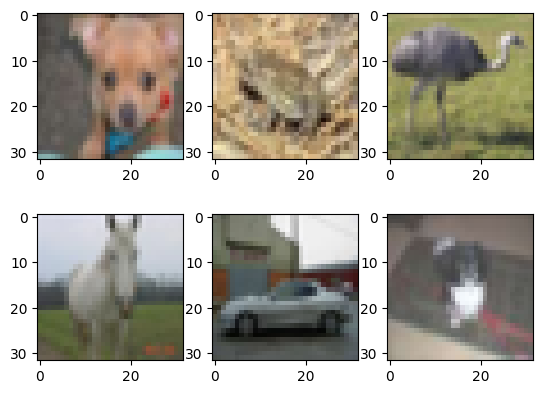

In [15]:
# device config 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# hyperparameters 
input_size = 3072
hidden_size = 2 # [2 - 300]  --> this is the hidden neurons not hidden layer 
num_classes = 10
num_epochs = 4
batch_size = 250
learning_rate = 0.0005 #[0.0005 - 0.5] try different rates here
init_wb_mode = "random" #can be: random or zero 

# import CIFAR 10 data set 
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, 
                                             transform=transforms.ToTensor(), download=True)

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, 
                                             transform=transforms.ToTensor(), download=True)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

examples = iter(train_loader)
samples, labels = examples.__next__()

print(samples.shape, labels.shape)
# output: torch.Size([250, 3, 32, 32]) torch.Size([250])  
# samples shape; 250 -> batch size; 3 --> channels (colours: rgb); image array --> 32x32
# labels shape: 250 -> batch size 


for i in range(6):
    plt.subplot(2, 3, i+1)

    img = samples[i].permute(1, 2, 0)  # (32,32,3)
    plt.imshow(img)

# plt.show()



# initialization mode for weights and biases in the network 

def init_weights_bias(model, mode="random"):
    for layer in model.modules():
        if isinstance(layer, nn.Linear):
            if mode == "random":
                # need to init the weights here to random small value from a uniform distribution
                # bias can be set to zero 
                nn.init.uniform_(layer.weight, -0.05, 0.05)
                nn.init.zeros_(layer.bias)
            elif mode == "zero":
                nn.init.zeros_(layer.weight)
                nn.init.zeros_(layer.bias)




class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet, self).__init__()
        self.l1 = nn.Linear(input_size, hidden_size)
        self.sigmoid = nn.Sigmoid()  # defined as: f(x) = 1 / (1 + e^-x)
        self.l2 = nn.Linear(hidden_size, num_classes)

    # this is the hidden layer and it is set to one as: input layer -> hidden layer : forward[l1 -> sigmoid -> l2] -> output layer
    def forward(self, x):
        out = self.l1(x) # layer one, gets x value 

        # Sigmoid function outputs in the range (0, 1), it is ideal to use for binary classification problems 
        # works well for finding the probability of the data belonging to a particular class
        # can learn more about the sigmoid function here: https://www.geeksforgeeks.org/python/python-tensorflow-nn-sigmoid/
        out = self.sigmoid(out) # takes previous output and outputs new value: 

        out = self.l2(out) # layer two, takes output from sigmoid 
        return out
model = NeuralNet(input_size, hidden_size, num_classes).to(device)
init_weights_bias(model, init_wb_mode)


# loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)


# training loop
n_total_steps = len(train_loader) 

error_hist_train = []
error_hist_test = []

for epoch in range(num_epochs):
    model.train()
    n_correct = 0
    n_samples = 0

    for i, (images, labels) in enumerate(train_loader):
        # need to reshape 
        images = images.reshape(images.size(0), -1).to(device)
        labels = labels.to(device)

        # forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # backwards pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        _, predictions = torch.max(outputs, 1)
        n_samples += labels.shape[0]
        n_correct += (predictions == labels).sum().item()

        if (i+1) % 100 == 0:
            print(f'epoch {epoch+1} / {num_epochs}, step {i+1}/{n_total_steps}, Training loss = {loss.item():.4f}')

    acc = 100 * n_correct / n_samples
    train_error = 1 - (n_correct / n_samples)
    error_hist_train.append(train_error)

    print(f'Training accuracy = {acc}')
    print(f'Training Error Rate: {train_error}')


    model.eval()
    # test
    with torch.no_grad():
        n_correct = 0
        n_samples = 0

        for images, labels in test_loader:
            images = images.reshape(images.size(0), -1).to(device)
            labels = labels.to(device)
            outputs = model(images)

            #value, index
            _, predictions = torch.max(outputs, 1)
            n_samples += labels.shape[0]
            n_correct += (predictions == labels).sum().item()

        acc = 100.0 * n_correct / n_samples
        print(f'Test accuracy = {acc}')

        test_error = 1 - (n_correct / n_samples)
        error_hist_test.append(test_error)
        print(f'Test Error rate: {test_error}')


# Rectified Linear Unit (ReLU):
# It is a piecewise linear function that outputs the input directly if it is positive; otherwise it outputs zero
# Can learn more by viewing the following link: https://www.geeksforgeeks.org/deep-learning/relu-activation-function-in-deep-learning/


# find mean across epochs of train and test error rates to get overall error rates 
final_error_train = np.mean(error_hist_train)
final_error_test = np.mean(error_hist_test)

print(f'Overall Training Error rate: {final_error_train}')
print(f'Overall Testing Error rate: {final_error_test}')